In [1]:
import numpy as np
from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

Baseline duration: 1 s
Mean, baseline: 0.97 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 2.4105263157894736 Hz


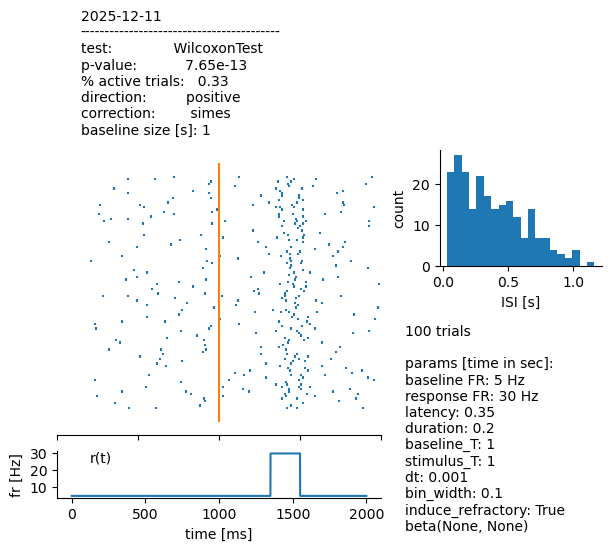

(<Figure size 600x400 with 4 Axes>,
 {'raster': <Axes: label='raster'>,
  'isi': <Axes: label='isi', xlabel='ISI [s]', ylabel='count'>,
  'text': <Axes: label='text'>,
  'r_t': <Axes: label='r_t', xlabel='time [ms]', ylabel='fr [Hz]'>})

In [ ]:
baseline_fr = 5
response_fr = 30
latency = 0.35
duration = 0.2
dt = 0.001
baseline_T = 1
stimulus_T = 1

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 100

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    
)

trial_activity = generator.generate(n_trials)



cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)

SpikeSummaryFigure(trial_activity, generator, detector, ).build()

Baseline duration: 1 s
Mean, baseline: 0.97 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 1.19 Hz


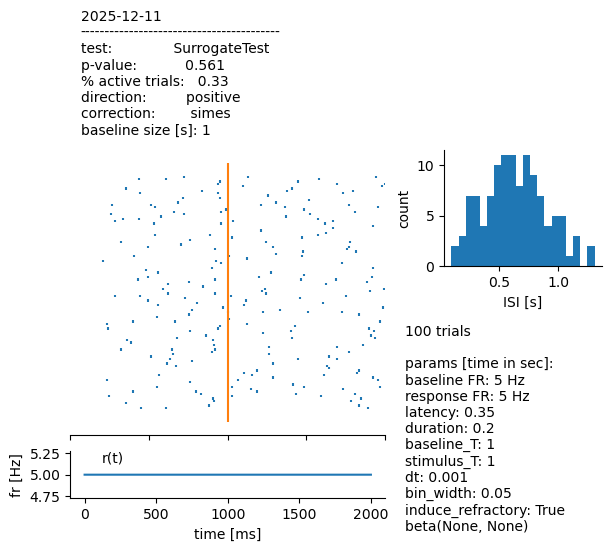

(<Figure size 600x400 with 4 Axes>,
 {'raster': <Axes: label='raster'>,
  'isi': <Axes: label='isi', xlabel='ISI [s]', ylabel='count'>,
  'text': <Axes: label='text'>,
  'r_t': <Axes: label='r_t', xlabel='time [ms]', ylabel='fr [Hz]'>})

In [3]:
cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.05,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": False,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, SurrogateTest, n_perms=1000)
detector.compute_min_pval()

SpikeSummaryFigure(trial_activity, generator, detector, ).build()

In [19]:
rng = np.random.default_rng(seed=73)
u = rng.uniform(size=100)

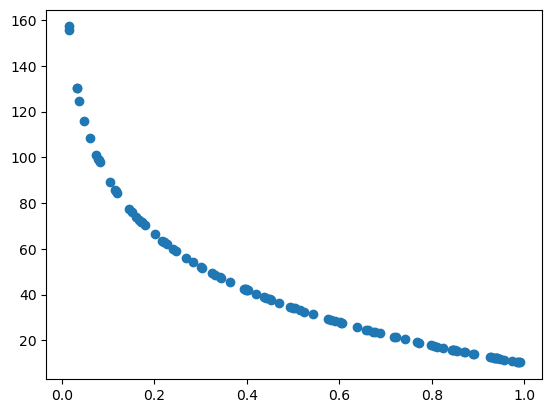

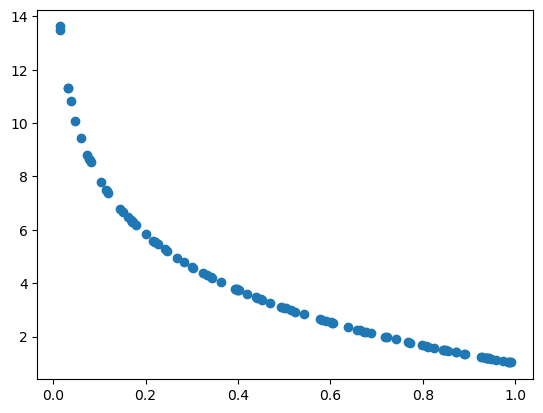

In [27]:
min_trial_num = 10
scale_trial = 35
plt.scatter(u, min_trial_num - scale_trial * np.log(u))
plt.show()


min_baseline_FR = 1
scale_trial = 3
plt.scatter(u, min_baseline_FR - scale_trial * np.log(u))
plt.show()

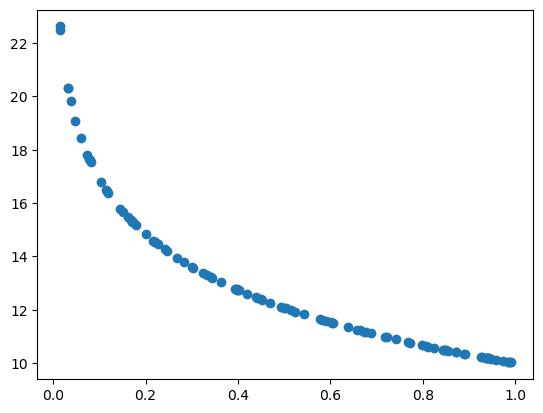

In [34]:
min_baseline_FR = 10
scale_trial = 3
plt.scatter(u, min_baseline_FR - scale_trial * np.log(u))
plt.show()